# Proyek Analisis Data: Bike-Sharing-Dataset
- **Nama:** Nur Adilah
- **Email:** nuradilah@students.usu.ac.id
- **ID Dicoding:** MC319D5X0793 NUR ADILAH

## Menentukan Pertanyaan Bisnis

- Bagaimana menentukan waktu yang optimal untuk menambah jumlah sepeda berdasarkan pola penyewaan harian?
- Apakah pelanggan lebih sering menggunakan sepeda untuk bekerja di hari kerja atau di akhir pekan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

## Data Wrangling

### Gathering Data

Setelah tahap Import semua Packages/Library yang akan digunakan selesai, kita bisa masuk ke tahap gathering data untuk mengumpulkan semua data yang dibutuhkan.


Data pertama yang harus kita muat ialah data dari tabel day.

In [2]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Data kedua yang harus kita muat ialah data dari tabel hour.

In [3]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Penyewaan sepeda tidak stabil sepanjang tahunnya dan sangat dipengaruhi dengan musim dan hari dalam seminggu.
- Penyewaan lebih tinggi di hari kerja dibandingkan akhir pekan.
- Cuaca cerah(1) meningkatkan penyewaan, sementara hujan(3) atau salju(3) menurunkannya.
- Penyewaan sepeda meningkat ketika suhu (~20-30°C) dan menurun ketika suhu lembab(hum) atau kecepatan angin tinggi(whindspeed).
- Penyewaan terbanyak terjadi di musim panas & gugur, sedangkan musim dingin memiliki jumlah penyewaan terendah.

### Assessing Data

**Menilai Data day_df**

Data pertama yang akan kita nilai adalah day_df. Sebagai permulaan, kita memeriksa tipe data dari tiap kolom yang terdapat dalam day_df.

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**

jika diperhatikan Tidak ada missing values Semua kolom memiliki 731 data lengkap. tetapi kolom dteday terlihat Dtype dengan tipe data object yang seharusnya tipe datanya datetime. Hal ini akan kita bersihkan pada tahap cleaning data.


Selanjutnya yang harus kita periksa ialah duplikasi data dan melakukan distribusi data Untuk mempermudah pemeriksaan, kita akan menggunakan method describe(). Method tersebut akan menampilkan ringkasan parameter statistik (mean, median, dll.) dari kolom numerik pada sebuah DataFrame.

In [5]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


Gambar diatas menunjukkan tidak ada terjadinya missing value pada dataset day_df.

In [6]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

day_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Tidak ada duplikat pada data day_df. Kemudian pada hasil distribusi pada tabel di atas menunjukkan bahwa Penyewaan sepeda bervariasi (22-8.714/hari), kemungkinan ada outlier. Pengguna registered lebih dominan, kelembaban(hum) 0% kemungkinan error, dan kecepatan angin 50.7 km/jam cukup ekstrem. Perlu cek lebih lanjut dengan boxplot.

**Menilai Data hour_df**

Data pertama yang akan kita nilai adalah hour_df. Sebagai permulaan, kita memeriksa tipe data dari tiap kolom yang terdapat dalam hour_df.

In [7]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight:**

Sama halnya seperti pada day_df, hour_df tidak ada missing values Semua kolom memiliki 17379 data lengkap, tetapi kolom dteday terlihat Dtype dengan tipe data object yang seharusnya tipe datanya datetime. Hal ini akan kita bersihkan pada tahap cleaning data.


In [8]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Sama seperti pada hasil distribusi pada day_df, hour_df juga memiliki hasil yang hampir mirip seperti penyewaan sepeda bervariasi (1-977/jam), kemungkinan ada outlier. Pengguna registered lebih dominan, sementara kelembaban(hum) dan kecepatan angin(windspeed) memiliki nilai 0, yang bisa jadi error. Weathersit maksimum 4, perlu dicek validitasnya. Perlu analisis lebih lanjut dengan boxplot pada tahapan Cleaning Data.

### Cleaning Data

**Konversi tipe data pada dataset day_df dan hour_df**

dimana dteday masi dalam format tipe data object, yang akan di konversikan ke tipe data datetime64.

In [9]:
# konversi tipe data untuk kolom dteday
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

print(day_df.dtypes)

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


Pada gambar diatas format tipe data pada kolom dteday sudah berubah menjadi datetime64


**Menanganai masalah Outlier pada dataset day_df**


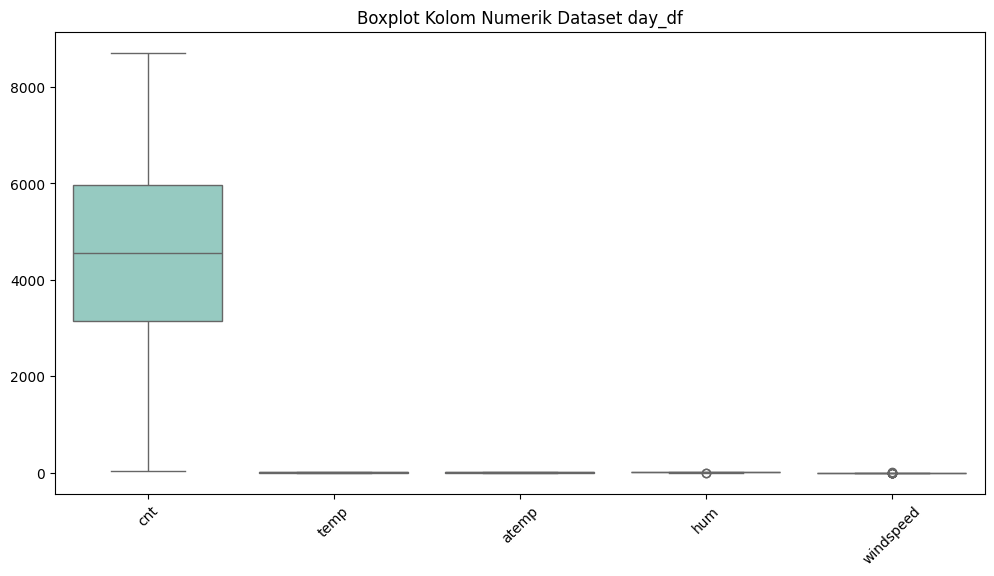

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=day_df[["cnt", "temp", "atemp", "hum", "windspeed"]], palette="Set3")
plt.xticks(rotation=45)
plt.title("Boxplot Kolom Numerik Dataset day_df")
plt.show()

Dapat dilihat dari gambar di atas kolom cnt, temp, dan atemp tidak memiliki outlier yang ekstrem dan distribusinya terlihat normal.

Kemudian pada kolom hum dan windspeed, keduanya memiliki outlier. Terdapat beberapa titik yang menandakan adanya nilai ekstrem. Hal ini akan dilakukan pengecekan.

In [11]:
day_df[["hum", "windspeed"]].describe().T

,count,mean,std,min,25%,50%,75%,max
hum,731.0,0.627894,0.142429,0.000000,0.52000,0.626667,0.730209,0.972500
windspeed,731.0,0.190486,0.077498,0.022392,0.13495,0.180975,0.233214,0.507463


terlihat pada gambar diatas
- nilai mean untuk kolom hum sekitar 0.63, std sekitar 0.14, kemudian nilai min 0.19, dan nilai max 0.97

- untuk kolom windspeed nilai mean sekitar 0.19, nilai std sekitar 0.08, nilai min sekitar 0.02, dan nilai max sekitar 0.51

Hal tersebut memungkinkan adanya outlier pada kolom hum dan windspeed. Kemungkinan hal ini memerlukan cleaning data untuk menangani outlier tersebut.

**Menghapus outlier dengan menggunakan metode IQR (Interquartile Range)**

In [12]:
# untuk kolom hum dan windspeed dimulai dengan menghitung Q1 dan Q3
Q1 = day_df[["hum", "windspeed"]].quantile(0.25)
Q3 = day_df[["hum", "windspeed"]].quantile(0.75)
IQR = Q3 - Q1

# menentukan batas bawah dan batas atas
IQR = Q3 - Q1

bawah = Q1 - (1.5 * IQR)
atas = Q3 + (1.5 * IQR)

# menghapus baris yang bernilai diluar batas tsb
day_df = day_df[~((day_df[["hum", "windspeed"]] < bawah) | (day_df[["hum", "windspeed"]] > atas)).any(axis=1)]

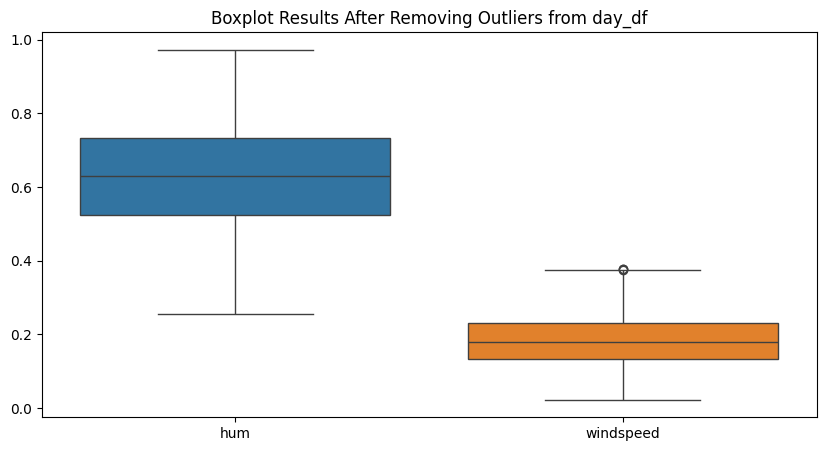

,count,mean,std,min,25%,50%,75%,max
hum,717.0,0.631562,0.139222,0.254167,0.524583,0.630833,0.732917,0.972500
windspeed,717.0,0.186287,0.071786,0.022392,0.134329,0.178496,0.230721,0.378108


In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(data=day_df[[ "hum", "windspeed"]])
plt.title("Boxplot Results After Removing Outliers from day_df")
plt.show()

day_df[["hum", "windspeed"]].describe().T

Penghapusan outlier menghilangkan 13 data tidak biasa, membuat data lebih bersih dan stabil. Dari hasil boxplot, terlihat kalau windspeed masih punya satu titik di luar whisker, berarti ada satu nilai yang mungkin masih bisa dianggap outlier. Humidity (hum) sudah terlihat rapi tanpa outlier. Distribusi data tetap konsisten dan siap untuk analisis selanjutnya

**Insight:**
- Setelah penghapusan Outlier, nilai hum dan windspeed lebih terdistribusi tanpa adanya nilai ekstrem.
- dari 731 data hanya 13 data yang di anggap outlier, artinya sebagian besar data sudah normal.
- Sebelum melakukan cleaning, nilai max windspeed sekitar 0.507. Setelah proses cleaning dan outlier di hapus nilainya turun menjadi 0.378.

**Menanganai masalah Outlier pada dataset hour_df dengan tahapan yang sama**

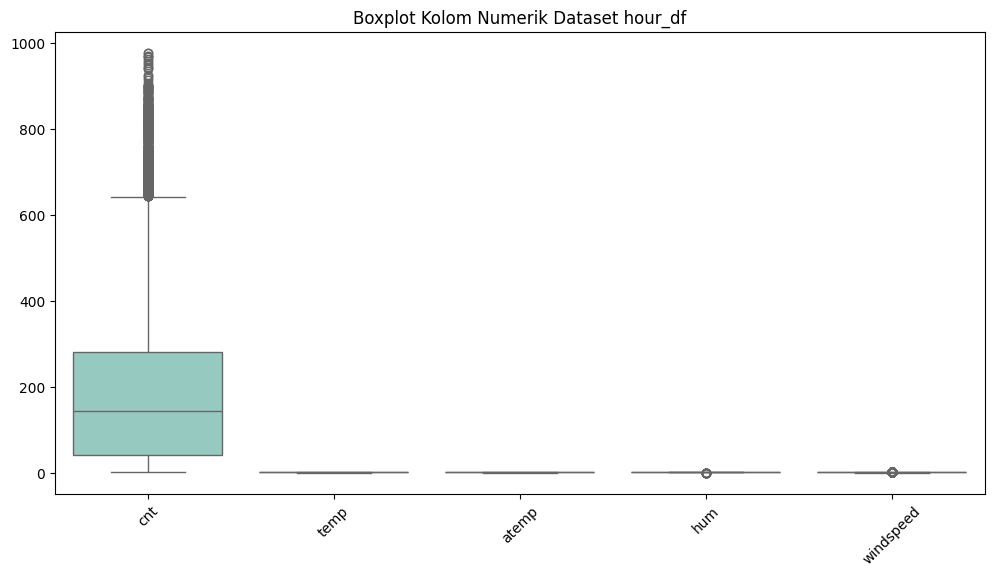

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=hour_df[["cnt", "temp", "atemp", "hum", "windspeed"]], palette="Set3")
plt.xticks(rotation=45)
plt.title("Boxplot Kolom Numerik Dataset hour_df")
plt.show()

Dari gambar diatas dapat terlihat pada kolom cnt terdapat banyak outlier pada bagian atas, artinya jumlah penyewaan sepeda sangat tinggi untuk beberapa ja, tertentu. Kemudian pada kolom hum dan windspeed terdapat outlier yang jumlahnya sedikit. Lalu untuk kolom temp dan atemp tidak memiliki outlier.

melakukan cleaning outlier pada kolom cnt

In [15]:
hour_df[["cnt"]].describe().T

,count,mean,std,min,25%,50%,75%,max
cnt,17379.0,189.463088,181.387599,1.0,40.0,142.0,281.0,977.0


In [16]:
# untuk kolom hum dan windspeed dimulai dengan menghitung Q1 dan Q3
Q1 = hour_df[["cnt"]].quantile(0.25)
Q3 = hour_df[["cnt"]].quantile(0.75)
IQR = Q3 - Q1

# menentukan batas bawah dan batas atas
IQR = Q3 - Q1

down = Q1 - (1.5 * IQR)
up = Q3 + (1.5 * IQR)

# menghapus baris yang bernilai diluar batas tsb
hour_df = hour_df[~((hour_df[["cnt"]] < down) | (hour_df[["cnt"]] > up)).any(axis=1)]
hour_df[['cnt']].describe()

,cnt
count,16874.000000
mean,172.710146
std,155.020918
min,1.000000
25%,38.000000
50%,135.000000
75%,265.750000
max,642.000000


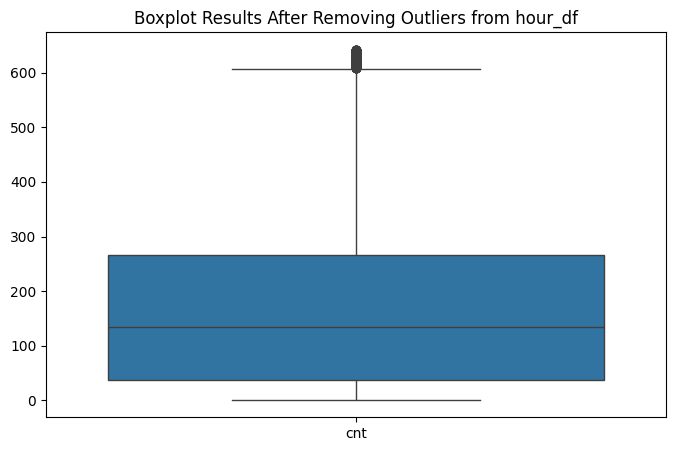

,count,mean,std,min,25%,50%,75%,max
cnt,16874.0,172.710146,155.020918,1.0,38.0,135.0,265.75,642.0


In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=hour_df[[ "cnt"]])
plt.title("Boxplot Results After Removing Outliers from hour_df")
plt.show()

hour_df[["cnt"]].describe().T

Setelah proses cleaning outlier, distribusi pada kolom cnt terlihat berkurang dari distribusi awal.

melakukan cleaning outlier pada kolom hum, dan windspeed

In [18]:
hour_df[["hum", "windspeed"]].describe().T

,count,mean,std,min,25%,50%,75%,max
hum,16874.0,0.630412,0.19260,0.0,0.4800,0.6300,0.7900,1.0000
windspeed,16874.0,0.189619,0.12246,0.0,0.1045,0.1791,0.2537,0.8507


terlihat pada gambar diatas

nilai mean untuk kolom hum sekitar 0.63, std sekitar 0.19, kemudian nilai min 0.0, dan nilai max 1.00

untuk kolom windspeed nilai mean sekitar 0.12, nilai std sekitar 0.08, nilai min sekitar 0.0, dan nilai max sekitar 0.85

In [19]:
# untuk kolom hum dan windspeed dimulai dengan menghitung Q1 dan Q3
Q1 = hour_df[["hum", "windspeed"]].quantile(0.25)
Q3 = hour_df[["hum", "windspeed"]].quantile(0.75)
IQR = Q3 - Q1

# menentukan batas bawah dan batas atas
IQR = Q3 - Q1

bawah = Q1 - (1.5 * IQR)
atas = Q3 + (1.5 * IQR)

# menghapus baris yang bernilai diluar batas tsb
hour_df = hour_df[~((hour_df[["hum", "windspeed"]] < bawah) | (hour_df[["hum", "windspeed"]] > atas)).any(axis=1)]
print(hour_df)

       instant     dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0            1 2011-01-01       1   0     1   0        0        6           0   
1            2 2011-01-01       1   0     1   1        0        6           0   
2            3 2011-01-01       1   0     1   2        0        6           0   
3            4 2011-01-01       1   0     1   3        0        6           0   
4            5 2011-01-01       1   0     1   4        0        6           0   
...        ...        ...     ...  ..   ...  ..      ...      ...         ...   
17374    17375 2012-12-31       1   1    12  19        0        1           1   
17375    17376 2012-12-31       1   1    12  20        0        1           1   
17376    17377 2012-12-31       1   1    12  21        0        1           1   
17377    17378 2012-12-31       1   1    12  22        0        1           1   
17378    17379 2012-12-31       1   1    12  23        0        1           1   

       weathersit  temp   a

Dari gambar tersebut proses cleaning outlier memiliki 17016 rows dan 17 columns

Mari verivikasi outlier sudah terhapus dengan membuat boxplot baru

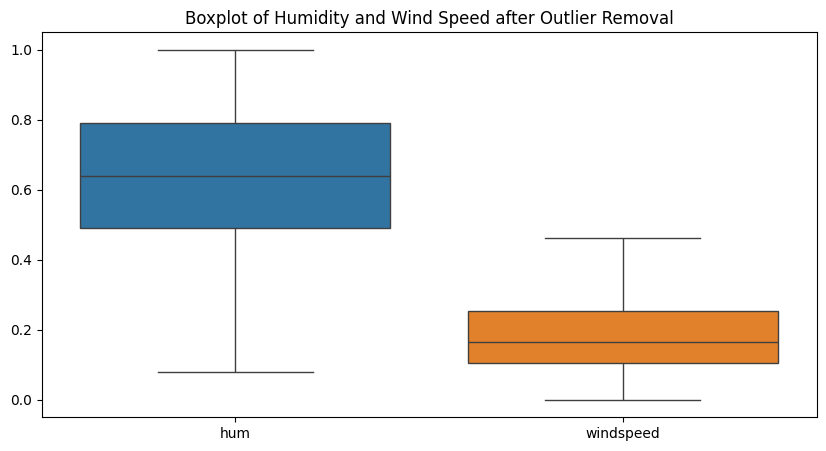

,count,mean,std,min,25%,50%,75%,max
hum,16522.0,0.634248,0.190030,0.08,0.4900,0.6400,0.7900,1.0000
windspeed,16522.0,0.182329,0.112087,0.00,0.1045,0.1642,0.2537,0.4627


In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=hour_df[[ "hum", "windspeed"]])
plt.title("Boxplot of Humidity and Wind Speed after Outlier Removal")
plt.show()

hour_df[["hum", "windspeed"]].describe().T

Setelah proses cleaning outlier, distribusi pada kolom hum dan windspeed terlihat normal tanpa adanya nilai ekstrem. Nilai mean pada kolom hum tetap di sekitar 0.63, sedangkan pada kolom windspeed  nilai mean sedikit menurun menjadi 0.18, ini menandakan nilai ektrem sebelumnya cukup berpengaruh.

## Exploratory Data Analysis (EDA)

### Explore ...

kita telah mendefinisikan beberapa pertanyaan bisnis seperti berikut.

1. Bagaimana menentukan waktu yang optimal untuk menambah jumlah sepeda berdasarkan pola penyewaan harian?
2. Apakah pelanggan lebih sering menggunakan sepeda untuk bekerja di hari kerja atau di akhir pekan?

Nah, sekarang tugas kita adalah membuat visualisasi data dan explanatory analysis guna menjawab berbagai pertanyaan tersebut.


**Insight:**
- Kita dapat mengetahui kapan jumlah sepeda yang tersedia harus ditambah berdasarkan pola penyewaan harian.
- Dari dataset (hour_df), kita dapat menghitung nilai mean pada penyewaan sepeda per jam dan memvisualisasikannya.
- Dengan analisis ini, kita bisa melihat apakah ada tren lebih banyak penyewaan di jam sibuk kerja atau saat liburan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana menentukan waktu yang optimal untuk menambah jumlah sepeda berdasarkan pola penyewaan harian?

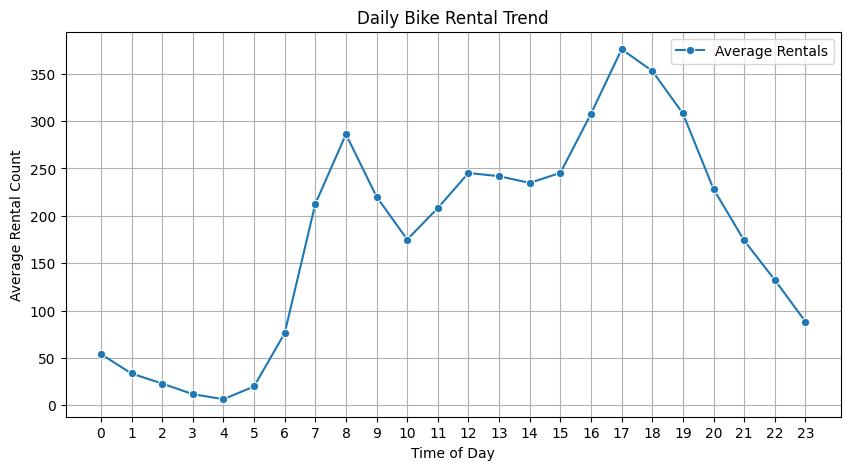

In [21]:
# Menghitung nilai mean pada penyewaan sepeda per jam
hourly_rental_average = hour_df.groupby('hr')['cnt'].mean()

# Membuat visualisasi tren penyewaan harian
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_rental_average.index, y=hourly_rental_average.values, marker="o", label="Average Rentals")
plt.title("Daily Bike Rental Trend")
plt.xlabel("Time of Day")
plt.ylabel("Average Rental Count")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

Dapat dilihat dari gambar di atas, waktu penyewaan sepeda pada pagi hari paling banyak pada jam 07.00 - 08.00, sedangkan pada sore hari terlihat pada jam 16.00 - 18.00.

Jadi, waktu yang optimal untuk menyediakan sepeda tambahan yaitu sebelum jam 07.00 pagi dan jam 16.00 sore

### Pertanyaan 2: Apakah pelanggan lebih sering menggunakan sepeda untuk bekerja di hari kerja atau di akhir pekan?

kita dapat membandingkan pola penyewaan sepeda pada hari kerja dan akhir pekan, untuk mengetahui berapa banyak sepeda yang harus disediakan

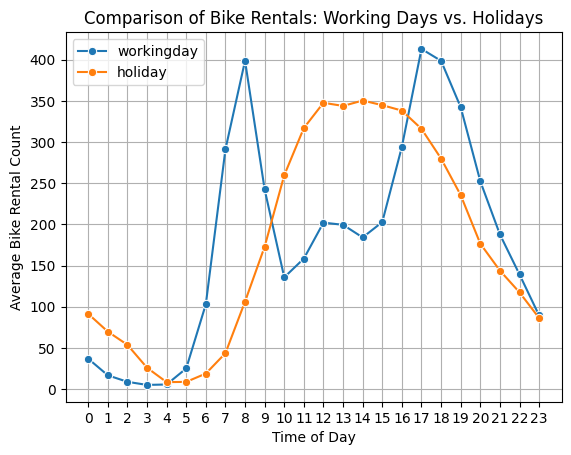

In [22]:
# Hari kerja
sns.lineplot(data=hour_df[hour_df['workingday'] == 1].groupby('hr')['cnt'].mean(), label="workingday", marker="o")

# Akhir pekan
sns.lineplot(data=hour_df[hour_df['workingday'] == 0].groupby('hr')['cnt'].mean(), label="holiday", marker="o")

# Konfigurasi plot
plt.title("Comparison of Bike Rentals: Working Days vs. Holidays")
plt.xlabel("Time of Day")
plt.ylabel("Average Bike Rental Count")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

Dapat dilihat dari gambar diatas rafik menunjukkan perbedaan pola penyewaan sepeda antara hari kerja dan akhir pekan. Pada hari kerja,  penyewaan terjadi sekitar pukul 08.00 pagi dan 17.00 - 18.00 sore, pada  jam kerja. Sementara itu, akhir pekan cenderung stabil di siang hingga sore hari. Maka, alokasi sepeda sebaiknya ditingkatkan pada pagi dan sore di hari kerja serta siang hingga sore di akhir pekan untuk memenuhi permintaan pengguna

**Insight:**
- Penyewaan sepeda paling banyak terjadi sekitar jam 07:00 - 09:00 pagi dan 17:00 - 19:00 sore.
- Terjadinya lonjakan pada penyewaan sepeda yang artinya banyak pengguna memakai sepeda untuk perjalanan kerja atau sekolah.
- Untuk memastikan ketersediaan sepeda, penambahan sepeda dapat dilakukan sebelum pukul 07:00 pagi dan sebelum pukul 17:00 sore.
- Pada hari kerja Penyewaan sepeda lebih berfokus pada pagi dan sore hari, sesuai dengan pola perjalanan kerja.
- Pada akhir pekan Penyewaan sepeda cenderung lebih merata setiap harinya, dan paling banyak terjadi sekitar 11:00 - 17:00, yang menunjukkan penggunaan lebih banyak untuk rekreasi atau aktivitas santai.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1:
Berdasarkan visualisasi tren penyewaan sepeda per jam, terdapat dua waktu utama dimana pada waktu tersebut banyak pengguna yang menyewa sepeda, yaitu pada pagi hari sekitar jam 07.00 - 08.00 dan sore hari sekitar jam 17.00 - 18.00.
Ini menunjukkan bahwa penggunaan sepeda meningkat saat jam kerja, kemungkinan besar karena orang-orang menggunakan sepeda untuk pergi dan pulang kerja/sekolah.
Oleh karena itu, menambah jumlah sepeda pada jam-jam tersebut dapat membantu memenuhi kebutuhan yang lebih tinggi dan mengurangi terjadinya kehabisan sepeda.


- Conclution pertanyaan 2:
Pola penyewaan sepeda cenderung lebih tinggi di hari kerja, terutama saat jam sibuk, karena banyak orang menggunakannya untuk pergi dan pulang kerja, sedangkan di akhir pekan, oleh karena itu penyewaan lebih merata sepanjang hari karena lebih banyak dipakai untuk rekreasi atau santai.